In [9]:
import numpy as np
import matplotlib.pyplot as plt
%load_ext autoreload
%autoreload 2

import sys
import os
sys.path.append(os.path.abspath('..'))

plt.rcParams.update({
    "text.usetex": True,           # Attiva l'uso di LaTeX per tutto il testo
    "font.family": "serif",        # Usa un font Serif per il testo normale
    "font.serif": ["Palatino"],    # Specifica Palatino (molto simile a quello in foto)
    "axes.labelsize": 16,          # Dimensione font etichette assi
    "font.size": 14,                # Dimensione font generale
    "legend.fontsize": 14,         # Dimensione font legenda
    "xtick.labelsize": 13,         # Dimensione numeri asse x
    "ytick.labelsize": 13,         # Dimensione numeri asse y
    "figure.figsize": (8, 6),      # Dimensione predefinita della figura
    "figure.dpi": 300,             # Risoluzione
    
    "text.latex.preamble": r"\usepackage{amsmath} \usepackage{amssymb}"
})



The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## **Data Representation**

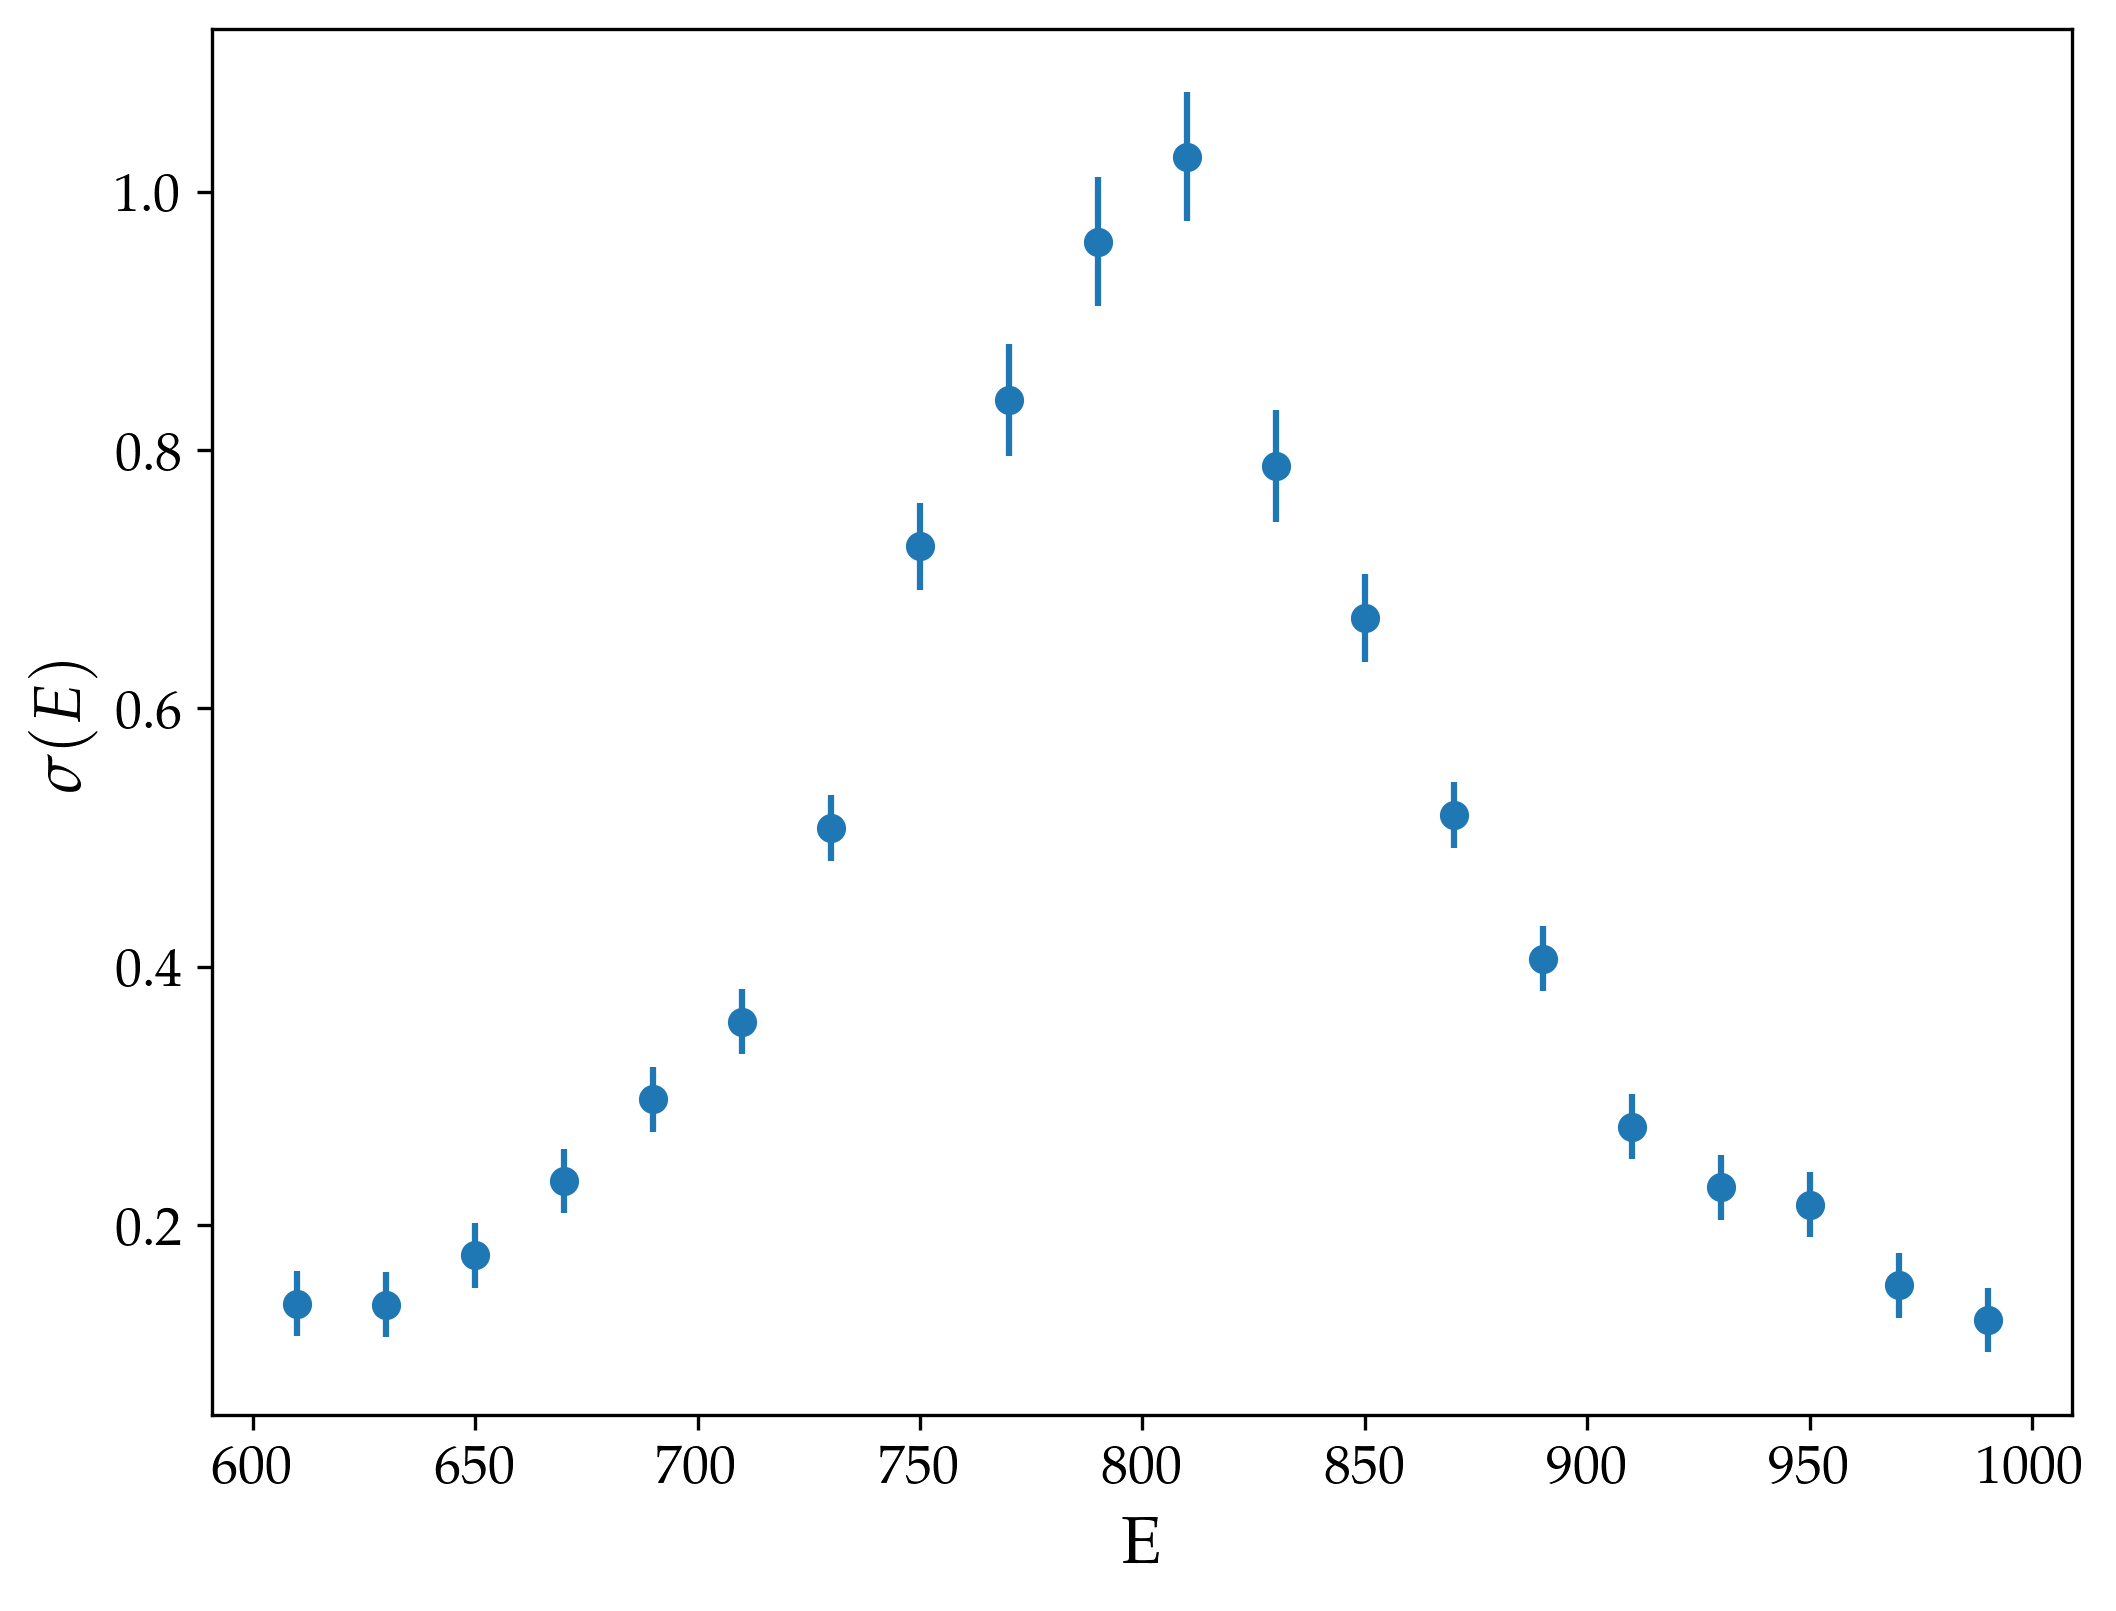

In [10]:
E, cs = np.loadtxt('data.txt', unpack=True)
cov = np.loadtxt('cov.txt')
errs = np.sqrt(np.diag(cov))

plt.scatter(E, cs)
plt.errorbar(E, cs, errs, ls='')

plt.xlabel('E')
plt.ylabel(r'$\sigma(E)$')
plt.savefig('plots/simple_points.png')
plt.show()

## **Fitting**

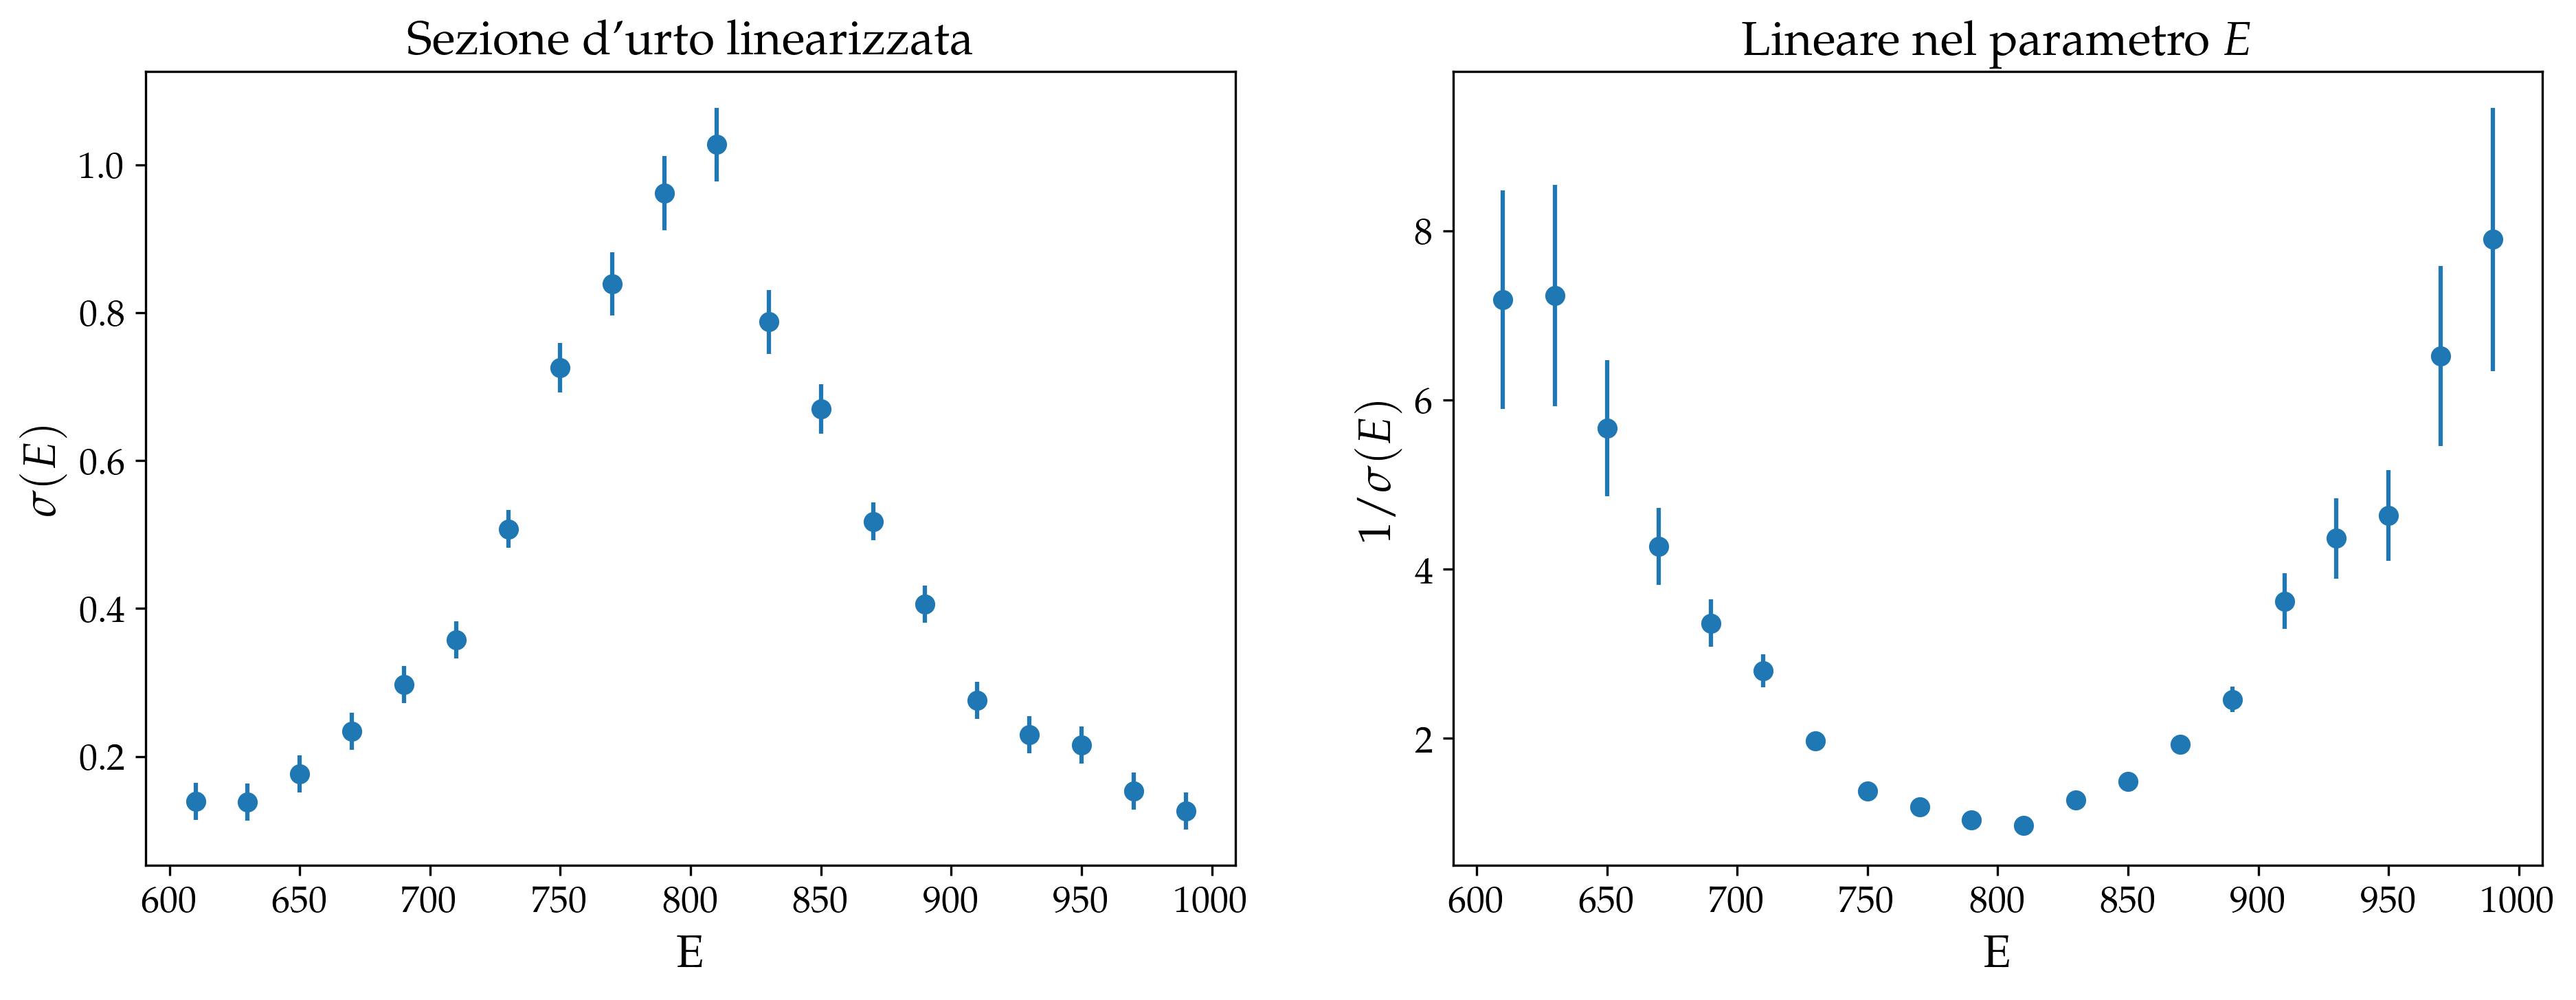

In [ ]:
lin_cov = (-1/cs**2)[:, None] * cov * (-1/cs**2)[None, :]

fig, ax = plt.subplots(1, 2, figsize=(15,5))

# Breit-Wigner
ax[0].scatter(E, cs) 
ax[0].errorbar(E, cs, np.sqrt(np.diag(cov)), ls='') 
ax[0].set_xlabel(r'$E$')
ax[0].set_ylabel(r'$\sigma(E)$')

# Linear E
ax[1].set_title(r'Lineare nel parametro $E$')
ax[1].scatter(E, 1/cs) 
ax[1].errorbar(E, 1/cs, np.sqrt(np.diag(lin_cov)), ls='') 
ax[1].set_xlabel(r'$E$')
ax[1].set_ylabel(r'$1/\sigma(E)$')

plt.savefig('plots/confr_lin_nonLin.png')
plt.show()

In [12]:
from lib_fitting import lin_fit, eval_Par
    
fa_ls = [
    lambda E: E**2,                 # f2: Relative to alpha_2
    lambda E: E,                    # f1: Relative to alpha_1
    lambda E: np.ones_like(E)       # f0: Relative to alpha_0
]
fa = np.array(fa_ls)

pars, cov_par, chi2, pval = lin_fit(E, 1/cs, lin_cov, fa)
a_par,b_par,c_par = pars

Par_Func_ls = [
    lambda a,b,c: 1/a,
    lambda a,b,c: - b*(1/a) / 2,
    lambda a,b,c: 2 * np.sqrt((1/a)*c - (- b*(1/a) / 2)**2)
]

new_pars, new_cov = eval_Par(Par_Func_ls, pars, cov_par)

F_par, M_par, G_par = new_pars 
err_par = np.sqrt(np.diag(new_cov))

print(f'F = {F_par:.1f} +/- {err_par[0]:.1f} Mev^2')
print(f'M = {M_par:.1f} +/- {err_par[1]:.1f} MeV')
print(f'G = {G_par:.1f} +/- {err_par[2]:.1f} Mev')
print()
print(f'Chi2 = {chi2:.1f}')
print(f'p-val = {pval:.2f}')


F = 5316.3 +/- 292.8 Mev^2
M = 799.9 +/- 1.2 MeV
G = 145.1 +/- 5.2 Mev

Chi2 = 13.5
p-val = 0.70


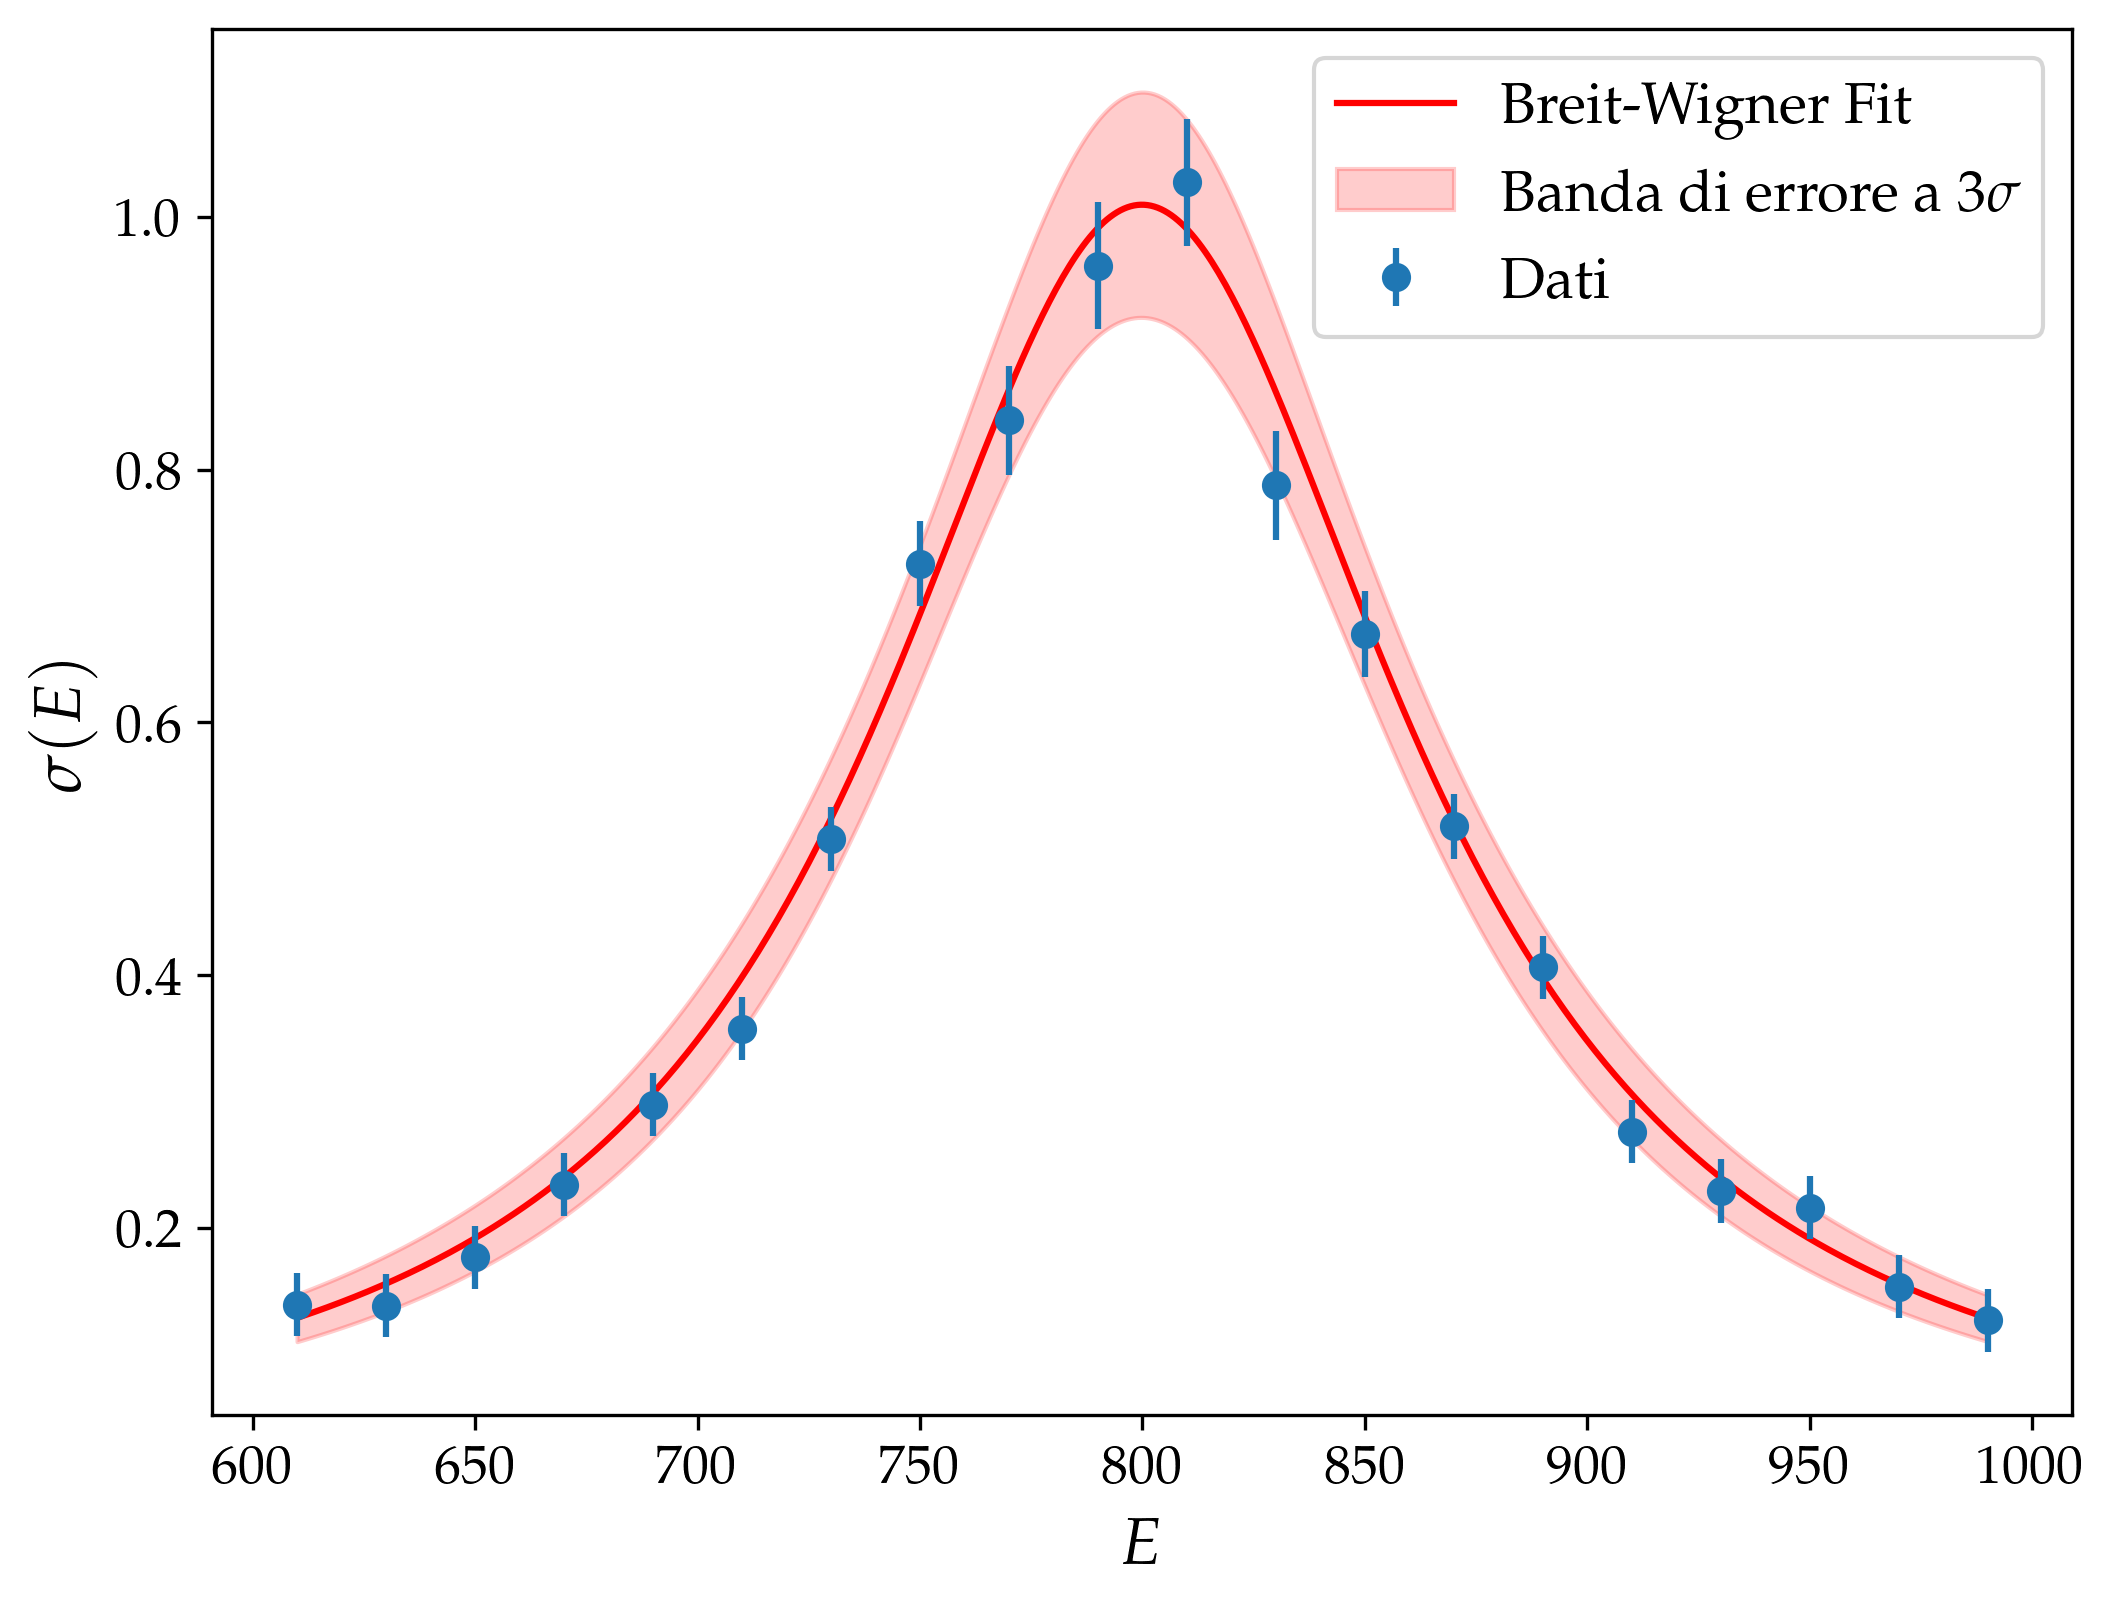

In [13]:
from lib_fitting import plot_fit

def sig_scatter(x, f, m, g):
    return f / ((x - m)**2 + (g/2)**2)

plot_fit(sig_scatter, E, cs, np.sqrt(np.diag(cov)), new_pars, new_cov,
         min(E), max(E), fit_name='Breit-Wigner Fit', nsigma=3,
         xlab=r'$E$', ylab=r'$\sigma(E)$')
